In [114]:
import numpy as np
import pandas as pd


In [115]:
df = pd.read_csv('Data/spam.csv',encoding="latin-1")

In [116]:
df.head()

,v1,v2,Unnamed: 2,Unnamed: 3,Unnamed: 4
0,ham,"Go until jurong point, crazy.. Available only ...",NaN,NaN,NaN
1,ham,Ok lar... Joking wif u oni...,NaN,NaN,NaN
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,NaN,NaN,NaN
3,ham,U dun say so early hor... U c already then say...,NaN,NaN,NaN
4,ham,"Nah I don't think he goes to usf, he lives aro...",NaN,NaN,NaN


In [117]:
# 1) data cleaning
# 2) EDA 
# 3) Text preproccesing
# 4) Model building
# 5) Evaluation
# 6) Improvement 
# 7) Website
# 8) Deployment

### Step 1. Data Cleaning

In [118]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 5572 entries, 0 to 5571
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype
---  ------      --------------  -----
 0   v1          5572 non-null   str  
 1   v2          5572 non-null   str  
 2   Unnamed: 2  50 non-null     str  
 3   Unnamed: 3  12 non-null     str  
 4   Unnamed: 4  6 non-null      str  
dtypes: str(5)
memory usage: 677.1 KB


In [119]:
# removing columns
df = df.drop(columns=['Unnamed: 2','Unnamed: 3','Unnamed: 4'])

In [120]:
df.head()

,v1,v2
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."


In [121]:
# rename column name
df = df.rename(columns={'v1':'target','v2':'text'})

In [122]:
df.head()

,target,text
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."


In [123]:
# converting target to number
from sklearn.preprocessing import LabelEncoder
encoder= LabelEncoder()
df['target'] = encoder.fit_transform(df['target'])

In [124]:
df.head()

,target,text
0,0,"Go until jurong point, crazy.. Available only ..."
1,0,Ok lar... Joking wif u oni...
2,1,Free entry in 2 a wkly comp to win FA Cup fina...
3,0,U dun say so early hor... U c already then say...
4,0,"Nah I don't think he goes to usf, he lives aro..."


In [125]:
# checking missing values
df.isnull().sum()

target    0
text      0
dtype: int64

In [126]:
# checking duplicates
df.duplicated().sum()

np.int64(403)

In [127]:
df = df.drop_duplicates(keep='first')

In [128]:
df.duplicated().sum()

np.int64(0)

In [129]:
df.shape

(5169, 2)

### Step 2. EDA

In [130]:
# checking the distribution of target column
df['target'].value_counts()

target
0    4516
1     653
Name: count, dtype: int64

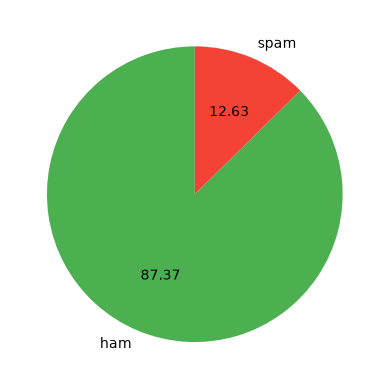

In [131]:
import matplotlib.pyplot as plt
plt.pie(df['target'].value_counts(),labels=['ham','spam'],autopct='%0.2f',colors = ['#4CAF50', '#F44336'],startangle=90)

In [132]:
import nltk


In [133]:
nltk.download('punkt')
nltk.download('punkt_tab')

[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\Hp\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to
[nltk_data]     C:\Users\Hp\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


True

In [134]:
df.head()

,target,text
0,0,"Go until jurong point, crazy.. Available only ..."
1,0,Ok lar... Joking wif u oni...
2,1,Free entry in 2 a wkly comp to win FA Cup fina...
3,0,U dun say so early hor... U c already then say...
4,0,"Nah I don't think he goes to usf, he lives aro..."


In [135]:
df['no_of_char'] = df['text'].apply(len)

In [136]:
df.head()

,target,text,no_of_char
0,0,"Go until jurong point, crazy.. Available only ...",111
1,0,Ok lar... Joking wif u oni...,29
2,1,Free entry in 2 a wkly comp to win FA Cup fina...,155
3,0,U dun say so early hor... U c already then say...,49
4,0,"Nah I don't think he goes to usf, he lives aro...",61


In [137]:
df['no_of_words'] = df['text'].apply(lambda x : len(nltk.word_tokenize(x)))

In [138]:
df.head()

,target,text,no_of_char,no_of_words
0,0,"Go until jurong point, crazy.. Available only ...",111,24
1,0,Ok lar... Joking wif u oni...,29,8
2,1,Free entry in 2 a wkly comp to win FA Cup fina...,155,37
3,0,U dun say so early hor... U c already then say...,49,13
4,0,"Nah I don't think he goes to usf, he lives aro...",61,15


In [139]:
df['no_of_sentence'] = df['text'].apply(lambda x : len(nltk.sent_tokenize(x)))

In [140]:
df.head()

,target,text,no_of_char,no_of_words,no_of_sentence
0,0,"Go until jurong point, crazy.. Available only ...",111,24,2
1,0,Ok lar... Joking wif u oni...,29,8,2
2,1,Free entry in 2 a wkly comp to win FA Cup fina...,155,37,2
3,0,U dun say so early hor... U c already then say...,49,13,1
4,0,"Nah I don't think he goes to usf, he lives aro...",61,15,1


In [141]:
df[['no_of_char','no_of_words','no_of_sentence']].describe()

,no_of_char,no_of_words,no_of_sentence
count,5169.000000,5169.000000,5169.000000
mean,78.977945,18.455794,1.965564
std,58.236293,13.324758,1.448541
min,2.000000,1.000000,1.000000
25%,36.000000,9.000000,1.000000
50%,60.000000,15.000000,1.000000
75%,117.000000,26.000000,2.000000
max,910.000000,220.000000,38.000000


In [142]:
df['target'].value_counts()

target
0    4516
1     653
Name: count, dtype: int64

In [143]:
# checking ham text
df[df['target']==0][['no_of_char','no_of_words','no_of_sentence']].describe()

,no_of_char,no_of_words,no_of_sentence
count,4516.000000,4516.000000,4516.000000
mean,70.459256,17.123782,1.820195
std,56.358207,13.493970,1.383657
min,2.000000,1.000000,1.000000
25%,34.000000,8.000000,1.000000
50%,52.000000,13.000000,1.000000
75%,90.000000,22.000000,2.000000
max,910.000000,220.000000,38.000000


In [144]:
# checking for spam
df[df['target']==1][['no_of_char','no_of_words','no_of_sentence']].describe()

,no_of_char,no_of_words,no_of_sentence
count,653.000000,653.000000,653.000000
mean,137.891271,27.667688,2.970904
std,30.137753,7.008418,1.488425
min,13.000000,2.000000,1.000000
25%,132.000000,25.000000,2.000000
50%,149.000000,29.000000,3.000000
75%,157.000000,32.000000,4.000000
max,224.000000,46.000000,9.000000


In [145]:
df.select_dtypes(include='number').corr()

,target,no_of_char,no_of_words,no_of_sentence
target,1.000000,0.384717,0.262912,0.263939
no_of_char,0.384717,1.000000,0.965760,0.624139
no_of_words,0.262912,0.965760,1.000000,0.679971
no_of_sentence,0.263939,0.624139,0.679971,1.000000


In [146]:
import seaborn as sns

<Axes: >

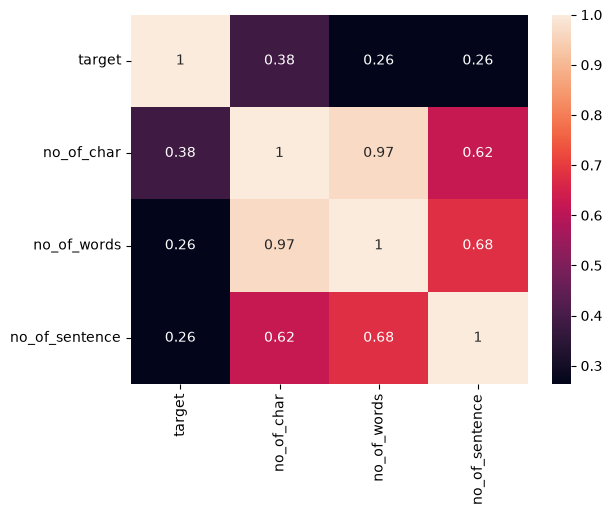

In [147]:
sns.heatmap(df.select_dtypes(include='number').corr(),annot=True)

### Step 3 Data Preprocessing
- Lower case
- Tokenization
- Removing Special characters
- Removing stopwords and punctuation
- stemming

In [148]:
from nltk.corpus import stopwords
import string
from nltk.stem import PorterStemmer

In [149]:
stemming = PorterStemmer()

In [150]:
def transform_text(text):
    transform1=text.lower()
    transform2 = nltk.word_tokenize(transform1)
    a = []
    for element in transform2:
        if element.isalnum():
            a.append(element)
    b = []        
    for element in a:
        if element not in stopwords.words('english') and element not in string.punctuation:
            b.append(element)

    c = []
    for element in b:
        c.append(stemming.stem(element))


    return " ".join(c)

In [151]:
df['tranformed_text'] = df['text'].apply(transform_text)

In [152]:
df.head()

,target,text,no_of_char,no_of_words,no_of_sentence,tranformed_text
0,0,"Go until jurong point, crazy.. Available only ...",111,24,2,go jurong point crazi avail bugi n great world...
1,0,Ok lar... Joking wif u oni...,29,8,2,ok lar joke wif u oni
2,1,Free entry in 2 a wkly comp to win FA Cup fina...,155,37,2,free entri 2 wkli comp win fa cup final tkt 21...
3,0,U dun say so early hor... U c already then say...,49,13,1,u dun say earli hor u c alreadi say
4,0,"Nah I don't think he goes to usf, he lives aro...",61,15,1,nah think goe usf live around though


In [153]:
from wordcloud import WordCloud
wc = WordCloud(width=500,height=500,min_font_size=10,background_color='white')

In [154]:
df[df['target']==1]['tranformed_text'].str.cat(sep=" ")

'free entri 2 wkli comp win fa cup final tkt 21st may text fa 87121 receiv entri question std txt rate c appli 08452810075over18 freemsg hey darl 3 week word back like fun still tb ok xxx std chg send rcv winner valu network custom select receivea prize reward claim call claim code kl341 valid 12 hour mobil 11 month u r entitl updat latest colour mobil camera free call mobil updat co free 08002986030 six chanc win cash 100 pound txt csh11 send cost 6day tsandc appli repli hl 4 info urgent 1 week free membership prize jackpot txt word claim 81010 c lccltd pobox 4403ldnw1a7rw18 xxxmobilemovieclub use credit click wap link next txt messag click http england v macedonia dont miss news txt ur nation team 87077 eg england 87077 tri wale scotland poboxox36504w45wq thank subscript rington uk mobil charg pleas confirm repli ye repli charg 07732584351 rodger burn msg tri call repli sm free nokia mobil free camcord pleas call 08000930705 deliveri tomorrow sm ac sptv new jersey devil detroit red w

In [155]:
spam_wc = wc.generate(df[df['target']==1]['tranformed_text'].str.cat(sep=" "))

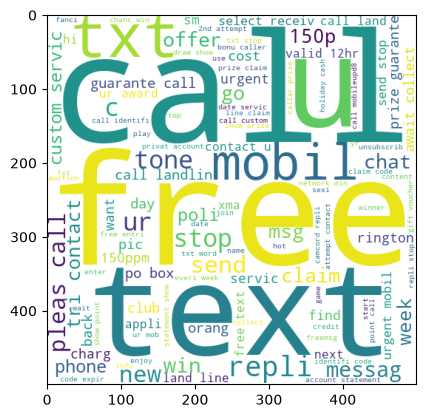

In [156]:
plt.imshow(spam_wc)

In [157]:
ham_wc = wc.generate(df[df['target']==0]['tranformed_text'].str.cat(sep=" "))

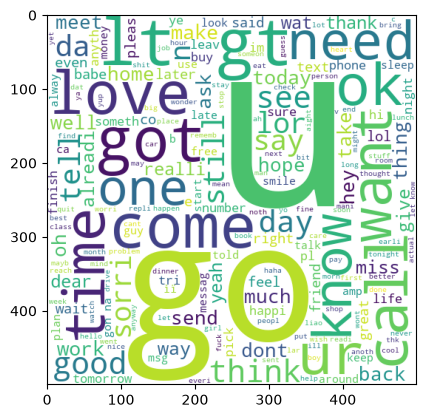

In [158]:
plt.imshow(ham_wc)

In [159]:
df.head()

,target,text,no_of_char,no_of_words,no_of_sentence,tranformed_text
0,0,"Go until jurong point, crazy.. Available only ...",111,24,2,go jurong point crazi avail bugi n great world...
1,0,Ok lar... Joking wif u oni...,29,8,2,ok lar joke wif u oni
2,1,Free entry in 2 a wkly comp to win FA Cup fina...,155,37,2,free entri 2 wkli comp win fa cup final tkt 21...
3,0,U dun say so early hor... U c already then say...,49,13,1,u dun say earli hor u c alreadi say
4,0,"Nah I don't think he goes to usf, he lives aro...",61,15,1,nah think goe usf live around though


In [160]:
#top 30 spam words
spam_corpus = []
df[df['target']==1]['tranformed_text'].to_list()


['free entri 2 wkli comp win fa cup final tkt 21st may text fa 87121 receiv entri question std txt rate c appli 08452810075over18',
 'freemsg hey darl 3 week word back like fun still tb ok xxx std chg send rcv',
 'winner valu network custom select receivea prize reward claim call claim code kl341 valid 12 hour',
 'mobil 11 month u r entitl updat latest colour mobil camera free call mobil updat co free 08002986030',
 'six chanc win cash 100 pound txt csh11 send cost 6day tsandc appli repli hl 4 info',
 'urgent 1 week free membership prize jackpot txt word claim 81010 c lccltd pobox 4403ldnw1a7rw18',
 'xxxmobilemovieclub use credit click wap link next txt messag click http',
 'england v macedonia dont miss news txt ur nation team 87077 eg england 87077 tri wale scotland poboxox36504w45wq',
 'thank subscript rington uk mobil charg pleas confirm repli ye repli charg',
 '07732584351 rodger burn msg tri call repli sm free nokia mobil free camcord pleas call 08000930705 deliveri tomorrow',
 '

In [161]:
spam_corpus =[]
for msg in df[df['target']==1]['tranformed_text'].to_list():
    for word in msg.split():
        spam_corpus.append(word)


In [162]:
spam_corpus

['free',
 'entri',
 '2',
 'wkli',
 'comp',
 'win',
 'fa',
 'cup',
 'final',
 'tkt',
 '21st',
 'may',
 'text',
 'fa',
 '87121',
 'receiv',
 'entri',
 'question',
 'std',
 'txt',
 'rate',
 'c',
 'appli',
 '08452810075over18',
 'freemsg',
 'hey',
 'darl',
 '3',
 'week',
 'word',
 'back',
 'like',
 'fun',
 'still',
 'tb',
 'ok',
 'xxx',
 'std',
 'chg',
 'send',
 'rcv',
 'winner',
 'valu',
 'network',
 'custom',
 'select',
 'receivea',
 'prize',
 'reward',
 'claim',
 'call',
 'claim',
 'code',
 'kl341',
 'valid',
 '12',
 'hour',
 'mobil',
 '11',
 'month',
 'u',
 'r',
 'entitl',
 'updat',
 'latest',
 'colour',
 'mobil',
 'camera',
 'free',
 'call',
 'mobil',
 'updat',
 'co',
 'free',
 '08002986030',
 'six',
 'chanc',
 'win',
 'cash',
 '100',
 'pound',
 'txt',
 'csh11',
 'send',
 'cost',
 '6day',
 'tsandc',
 'appli',
 'repli',
 'hl',
 '4',
 'info',
 'urgent',
 '1',
 'week',
 'free',
 'membership',
 'prize',
 'jackpot',
 'txt',
 'word',
 'claim',
 '81010',
 'c',
 'lccltd',
 'pobox',
 '4403ldnw

In [163]:
len(spam_corpus)

9939

In [164]:
from collections import Counter
top_spam_words= pd.DataFrame(Counter(spam_corpus).most_common(30),
                         columns=['word', 'count'])

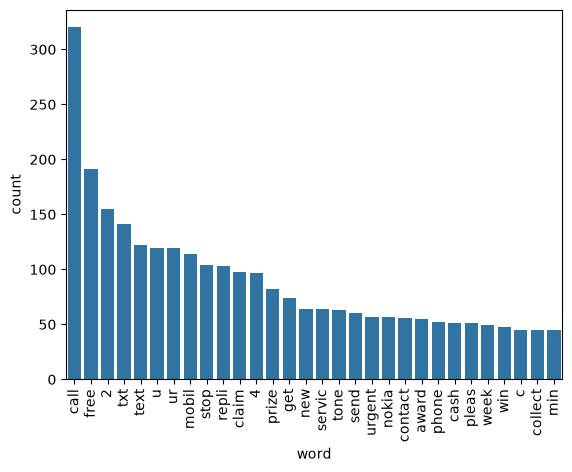

In [165]:
sns.barplot(data=top_spam_words, x='word', y='count')
plt.xticks(rotation='vertical')
plt.show()

In [166]:
# top ham words
ham_corpus =[]
for msg in df[df['target']==0]['tranformed_text'].to_list():
    for word in msg.split():
        ham_corpus.append(word)

In [167]:
top_ham_words= pd.DataFrame(Counter(ham_corpus).most_common(30),
                         columns=['word', 'count'])

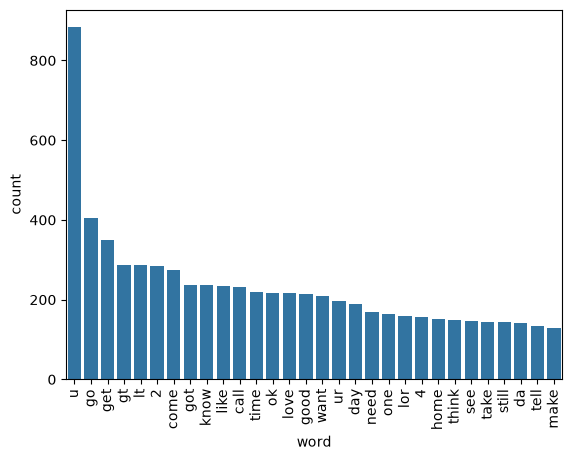

In [168]:
sns.barplot(data=top_ham_words, x='word', y='count')
plt.xticks(rotation='vertical')
plt.show()

### Model Building

In [169]:
df.head()

,target,text,no_of_char,no_of_words,no_of_sentence,tranformed_text
0,0,"Go until jurong point, crazy.. Available only ...",111,24,2,go jurong point crazi avail bugi n great world...
1,0,Ok lar... Joking wif u oni...,29,8,2,ok lar joke wif u oni
2,1,Free entry in 2 a wkly comp to win FA Cup fina...,155,37,2,free entri 2 wkli comp win fa cup final tkt 21...
3,0,U dun say so early hor... U c already then say...,49,13,1,u dun say earli hor u c alreadi say
4,0,"Nah I don't think he goes to usf, he lives aro...",61,15,1,nah think goe usf live around though


In [170]:
from sklearn.feature_extraction.text import CountVectorizer
cv = CountVectorizer()

In [171]:
X = cv.fit_transform(df['tranformed_text']).toarray()

In [172]:
y = df['target']

In [173]:
y

0       0
1       0
2       1
3       0
4       0
       ..
5567    1
5568    0
5569    0
5570    0
5571    0
Name: target, Length: 5169, dtype: int64

In [174]:
from sklearn.model_selection import train_test_split

In [175]:
X_train,X_test,y_train,y_test = train_test_split(X,y , test_size = 0.2 , random_state=42)

In [176]:
from sklearn.naive_bayes import GaussianNB , MultinomialNB, BernoulliNB

In [177]:
gnb = GaussianNB()
mnb = MultinomialNB()
bnb = BernoulliNB()

In [178]:
from sklearn.metrics import accuracy_score,confusion_matrix,precision_score

In [179]:
gnb.fit(X_train,y_train)
y_pred1 = gnb.predict(X_test)
print(accuracy_score(y_test,y_pred1))
print(confusion_matrix(y_test,y_pred1))
print(precision_score(y_test,y_pred1))

0.8684719535783365
[[772 117]
 [ 19 126]]
0.5185185185185185


In [180]:
mnb.fit(X_train,y_train)
y_pred2 = mnb.predict(X_test)
print(accuracy_score(y_test,y_pred2))
print(confusion_matrix(y_test,y_pred2))
print(precision_score(y_test,y_pred2))

0.9738878143133463
[[872  17]
 [ 10 135]]
0.8881578947368421


In [181]:
bnb.fit(X_train,y_train)
y_pred3 = bnb.predict(X_test)
print(accuracy_score(y_test,y_pred3))
print(confusion_matrix(y_test,y_pred3))
print(precision_score(y_test,y_pred3))

0.9661508704061895
[[885   4]
 [ 31 114]]
0.9661016949152542


In [ ]:
# trying with another vectorizer 
# i.e tfidf

from sklearn.feature_extraction.text import TfidfVectorizer
#tfidf = TfidfVectorizer(max_features=3000)
tfidf = TfidfVectorizer(max_features=3000)

In [183]:
X = tfidf.fit_transform(df['tranformed_text']).toarray()

In [184]:
X.shape

(5169, 3000)

In [185]:
y = df['target']

In [186]:
y

0       0
1       0
2       1
3       0
4       0
       ..
5567    1
5568    0
5569    0
5570    0
5571    0
Name: target, Length: 5169, dtype: int64

In [187]:
X_train,X_test,y_train,y_test = train_test_split(X,y , test_size = 0.2 , random_state=42)

In [188]:
gnb1 = GaussianNB()
mnb1 = MultinomialNB()
bnb1 = BernoulliNB()

In [189]:
gnb1.fit(X_train,y_train)
y_pred11 = gnb1.predict(X_test)
print(accuracy_score(y_test,y_pred11))
print(confusion_matrix(y_test,y_pred11))
print(precision_score(y_test,y_pred11))

0.8626692456479691
[[771 118]
 [ 24 121]]
0.5062761506276151


In [190]:
mnb1.fit(X_train,y_train)
y_pred12 = mnb1.predict(X_test)
print(accuracy_score(y_test,y_pred12))
print(confusion_matrix(y_test,y_pred12))
print(precision_score(y_test,y_pred12))

0.9729206963249516
[[888   1]
 [ 27 118]]
0.9915966386554622


In [191]:
bnb1.fit(X_train,y_train)
y_pred13 = bnb1.predict(X_test)
print(accuracy_score(y_test,y_pred13))
print(confusion_matrix(y_test,y_pred13))
print(precision_score(y_test,y_pred13))

0.9729206963249516
[[884   5]
 [ 23 122]]
0.9606299212598425


### checking with multiple algorithms

In [192]:
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.naive_bayes import BernoulliNB
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import AdaBoostClassifier
from sklearn.ensemble import BaggingClassifier
from sklearn.ensemble import ExtraTreesClassifier
from sklearn.ensemble import GradientBoostingClassifier
from xgboost import XGBClassifier

In [193]:
svc = SVC(kernel='sigmoid',gamma = 1.0)
knc = KNeighborsClassifier()
bnb = BernoulliNB()
dtc = DecisionTreeClassifier(max_depth=5)
lrc = LogisticRegression(solver='liblinear',penalty='l1')
rfc = RandomForestClassifier(n_estimators=50 , random_state=2)
abc = AdaBoostClassifier(n_estimators=50 ,random_state=2)
bc = BaggingClassifier(n_estimators=50 , random_state=2)
etc = ExtraTreesClassifier(n_estimators=50,random_state=2)
gbdt = GradientBoostingClassifier(n_estimators=50,random_state=2)
xgb = XGBClassifier(n_estimator=50,random_state =2)

In [194]:
clfs = {
    'SVC': svc,
    'KN' : knc,
    'NB':bnb,
    'DT':dtc,
    'LR':lrc,
    'RF':rfc,
    'Adaboost':abc,
    'BgC' :bc,
    'ETC':etc,
    'GBDT':gbdt,
    'xgb':xgb
}

In [195]:
def train_classifier(clf,X_train,y_train,X_test,y_test):
    clf.fit(X_train,y_train)
    y_pred = clf.predict(X_test)
    accuracy = accuracy_score(y_test,y_pred)
    precision = precision_score(y_test,y_pred)

    return accuracy,precision

In [196]:
train_classifier(svc,X_train,y_train,X_test,y_test)

(0.9758220502901354, 0.9477611940298507)

In [197]:
accuracy_scores = []
precision_scores = []

for name,clf in clfs.items():
    current_accuracy,current_precision = train_classifier(clf,X_train,y_train,X_test,y_test)

    print('For', name)
    print('accuracy' ,current_accuracy )
    print('precision' ,current_precision)

    accuracy_scores.append(current_accuracy)
    precision_scores.append(current_precision)

For SVC
accuracy 0.9758220502901354
precision 0.9477611940298507


c:\SHAAN\Projects\SMSspamDetection\venv\Lib\site-packages\joblib\externals\loky\backend\context.py:131: UserWarning: Could not find the number of physical cores for the following reason:
[WinError 2] The system cannot find the file specified
Returning the number of logical cores instead. You can silence this warning by setting LOKY_MAX_CPU_COUNT to the number of cores you want to use.
  warnings.warn(
  File "c:\SHAAN\Projects\SMSspamDetection\venv\Lib\site-packages\joblib\externals\loky\backend\context.py", line 247, in _count_physical_cores
    cpu_count_physical = _count_physical_cores_win32()
  File "c:\SHAAN\Projects\SMSspamDetection\venv\Lib\site-packages\joblib\externals\loky\backend\context.py", line 299, in _count_physical_cores_win32
    cpu_info = subprocess.run(
        "wmic CPU Get NumberOfCores /Format:csv".split(),
        capture_output=True,
        text=True,
    )
  File "C:\Users\Hp\AppData\Local\Programs\Python\Python313\Lib\subprocess.py", line 554, in run
    wi

For KN
accuracy 0.9148936170212766
precision 1.0
For NB
accuracy 0.9729206963249516
precision 0.9606299212598425
For DT
accuracy 0.9323017408123792
precision 0.8205128205128205


c:\SHAAN\Projects\SMSspamDetection\venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1403: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead of penalty=None.
  warnings.warn(
c:\SHAAN\Projects\SMSspamDetection\venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1429: UserWarning: Inconsistent values: penalty=l1 with l1_ratio=0.0. penalty is deprecated. Please use l1_ratio only.
  warnings.warn(


For LR
accuracy 0.9468085106382979
precision 0.8629032258064516
For RF
accuracy 0.971953578336557
precision 0.9915254237288136
For Adaboost
accuracy 0.913926499032882
precision 0.7916666666666666
For BgC
accuracy 0.960348162475822
precision 0.8768115942028986
For ETC
accuracy 0.9796905222437138
precision 1.0
For GBDT
accuracy 0.9497098646034816
precision 0.9514563106796117


c:\SHAAN\Projects\SMSspamDetection\venv\Lib\site-packages\xgboost\training.py:200: UserWarning: [11:04:06] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:793: 
Parameters: { "n_estimator" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


For xgb
accuracy 0.9690522243713733
precision 0.937984496124031


In [198]:
temp_df = pd.DataFrame({'Algorithm':clfs.keys(),'Accuracy_max_ft_3000':accuracy_scores,'Precision_max_ft_3000':precision_scores}).sort_values('Precision_max_ft_3000',ascending=False)

In [199]:
temp_df

,Algorithm,Accuracy_max_ft_3000,Precision_max_ft_3000
1,KN,0.914894,1.000000
8,ETC,0.979691,1.000000
5,RF,0.971954,0.991525
2,NB,0.972921,0.960630
9,GBDT,0.949710,0.951456
0,SVC,0.975822,0.947761
10,xgb,0.969052,0.937984
7,BgC,0.960348,0.876812
4,LR,0.946809,0.862903
3,DT,0.932302,0.820513


In [111]:
performance_df.merge(temp_df,on='Algorithm')

,Algorithm,Accuracy,Precision,Accuracy_max_ft_3000,Precision_max_ft_3000
0,KN,0.904255,1.000000,0.904255,1.000000
1,RF,0.967118,1.000000,0.967118,1.000000
2,ETC,0.971954,0.991525,0.971954,0.991525
3,NB,0.966151,0.966102,0.966151,0.966102
4,xgb,0.971954,0.946154,0.971954,0.946154
5,LR,0.970986,0.945736,0.970986,0.945736
6,DT,0.924565,0.935065,0.923598,0.923077
7,BgC,0.954545,0.888889,0.954545,0.888889
8,GBDT,0.934236,0.881188,0.934236,0.881188
9,Adaboost,0.907157,0.865672,0.907157,0.865672


In [200]:
performance_df= pd.DataFrame({'Algorithm':clfs.keys(),'Accuracy':accuracy_scores,'Precision':precision_scores}).sort_values('Precision',ascending=False)

In [201]:
performance_df

,Algorithm,Accuracy,Precision
1,KN,0.914894,1.000000
8,ETC,0.979691,1.000000
5,RF,0.971954,0.991525
2,NB,0.972921,0.960630
9,GBDT,0.949710,0.951456
0,SVC,0.975822,0.947761
10,xgb,0.969052,0.937984
7,BgC,0.960348,0.876812
4,LR,0.946809,0.862903
3,DT,0.932302,0.820513


### Model Improvement

In [202]:
#  1) tfidf max_features=3000

In [204]:
import pickle
pickle.dump(tfidf,open('vectorizer.pkl','wb'))
pickle.dump(mnb1,open('model.pkl','wb'))